In [ ]:
print("hi")

hi


In [ ]:
products = [
    {"name": "laptop", "price": 900, "category": "electronics"},
    {"name": "mouse", "price": 25, "category": "electronics"},
    {"name": "monitor", "price": 300, "category": "electronics"},
    {"name": "desk", "price": 150, "category": "furniture"},
    {"name": "lamp", "price": 30, "category": "furniture"},
]


In [ ]:
def expensive(items):
    result = []
    for i in items:
        if i["price"] > 50:
            result.append(i["name"])
    return result

print(expensive(products))

['laptop', 'monitor', 'desk']


In [ ]:
def long_words(words, min_length=4):     # min_length is a parameter with a default
    result = []
    for w in words:
        if len(w) > min_length:
            result.append(w)
    return result

print(long_words(["cat", "python", "api", "agent"]))       # uses default 4 → ['python', 'agent']
print(long_words(["cat", "python", "api", "agent"], 5))    # uses 5 → ['python']

In [ ]:
def expensive(items, min_price = 100):
    result = []
    for i in items:
        if i["price"] > min_price:
            result.append(i["name"])
    return result

print(expensive(products))

['laptop', 'monitor', 'desk']


In [ ]:
expensive(products, 200)

['laptop', 'monitor']

In [ ]:
count_by_category = [
    {"name": "laptop", "price": 900, "category": "electronics"},
    {"name": "mouse", "price": 25, "category": "electronics"},
    {"name": "monitor", "price": 300, "category": "electronics"},
    {"name": "desk", "price": 150, "category": "furniture"},
    {"name": "lamp", "price": 30, "category": "furniture"},
]





In [ ]:
def count_by_category(product):
  result = {}
  for pro in product:
    cat = pro["category"]
    if pro in result:
      result[cat] +=1
    else:
      result[cat] = 1
  return result

  print(count_by_category(products))

In [ ]:
import os

In [ ]:
current_dir = os.getcwd()

In [ ]:
print(current_dir)

/content


In [ ]:
import requests

response = requests.get("https://api.open-meteo.com/v1/forecast?latitude=51.23&longitude=6.77&current=temperature_2m")

print(response.status_code)

data = response.json()
print(data)

200
{'latitude': 51.232, 'longitude': 6.757, 'generationtime_ms': 0.031948089599609375, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 25.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C'}, 'current': {'time': '2026-10-02T09:15', 'interval': 900, 'temperature_2m': 16.9}}


In [ ]:
{
  'latitude': 51.22,
  'longitude': 6.78,
  'timezone': 'GMT',
  'current_units': {'time': 'iso8601', 'temperature_2m': '°C'},
  'current': {'time': '2026-10-02T10:00', 'interval': 900, 'temperature_2m': 13.4}
}

{'latitude': 51.22,
 'longitude': 6.78,
 'timezone': 'GMT',
 'current_units': {'time': 'iso8601', 'temperature_2m': '°C'},
 'current': {'time': '2026-10-02T10:00',
  'interval': 900,
  'temperature_2m': 13.4}}

In [ ]:
print(data.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'current_units', 'current'])


In [ ]:
print(data["current"]["temperature_2m"])

16.9


In [ ]:
import requests

def get_temperature(lat, lon):
    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m"
    response = requests.get(url, timeout=10)
    data = response.json()
    return data["current"]["temperature_2m"]
#print(data.keys())

#print(get_temperature(51.23, 6.77))   # Düsseldorf
print(get_temperature(52.52, 13.41))  # Berlin

15.8


In [ ]:
import requests

url = "https://api.open-meteo.com/v1/forecast?latitude=51.23&longitude=6.77&hourly=temperature_2m&forecast_days=3&timezone=Europe/Berlin"
response = requests.get(url, timeout=10)
data = response.json()

print(data["hourly"].keys())

dict_keys(['time', 'temperature_2m'])


In [ ]:
print(data["hourly"]["time"][:5])
print(data["hourly"]["temperature_2m"][:5])

['2026-10-02T00:00', '2026-10-02T01:00', '2026-10-02T02:00', '2026-10-02T03:00', '2026-10-02T04:00']
[17.8, 17.0, 16.8, 15.9, 14.8]


In [ ]:
print(data.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [ ]:
print(data["hourly"].keys())

dict_keys(['time', 'temperature_2m'])


In [ ]:
import pandas as pd

df =   pd.DataFrame(data["hourly"])
print(df.head())

               time  temperature_2m
0  2026-10-02T00:00            17.8
1  2026-10-02T01:00            17.0
2  2026-10-02T02:00            16.8
3  2026-10-02T03:00            15.9
4  2026-10-02T04:00            14.8


In [ ]:
df.shape

(72, 2)

In [ ]:
print(df.dtypes)

time               object
temperature_2m    float64
dtype: object


In [ ]:
df["time"] = pd.to_datetime(df["time"])

In [ ]:
df.dtypes

,0
time,datetime64[ns]
temperature_2m,float64


In [ ]:
df["weekday"] = df["time"].dt.day_name()
print(df.head())

                 time  temperature_2m weekday
0 2026-10-02 00:00:00            17.8  Friday
1 2026-10-02 01:00:00            17.0  Friday
2 2026-10-02 02:00:00            16.8  Friday
3 2026-10-02 03:00:00            15.9  Friday
4 2026-10-02 04:00:00            14.8  Friday


In [ ]:
df["hour"] = df["time"].dt.hour

In [ ]:
df.head()

,time,temperature_2m,weekday,hour
0,2026-10-02 00:00:00,17.8,Friday,0
1,2026-10-02 01:00:00,17.0,Friday,1
2,2026-10-02 02:00:00,16.8,Friday,2
3,2026-10-02 03:00:00,15.9,Friday,3
4,2026-10-02 04:00:00,14.8,Friday,4


In [ ]:
print(df["temperature_2m"].mean())   # average
print(df["temperature_2m"].max())    # highest
print(df["temperature_2m"].min())    # lowest

17.626388888888886
22.8
13.4


In [ ]:
df.head()

,time,temperature_2m,weekday,hour
0,2026-10-02 00:00:00,17.8,Friday,0
1,2026-10-02 01:00:00,17.0,Friday,1
2,2026-10-02 02:00:00,16.8,Friday,2
3,2026-10-02 03:00:00,15.9,Friday,3
4,2026-10-02 04:00:00,14.8,Friday,4


In [ ]:
print(len(df[df['temperature_2m'] < 10]))

0


In [ ]:
print(df["temperature_2m"].min())

13.4


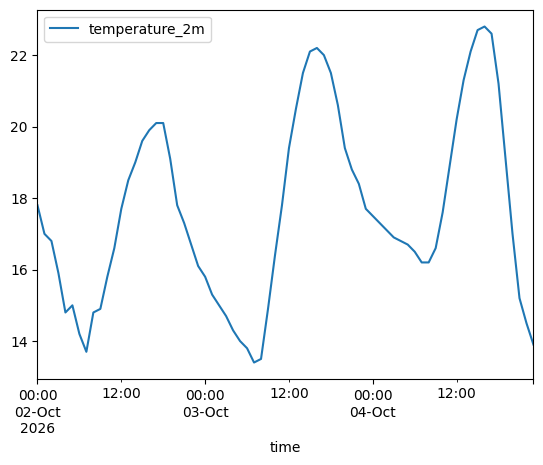

In [ ]:
import matplotlib.pyplot as plt

df.plot(x="time", y="temperature_2m")
plt.show()

Text(0, 0.5, 'temperature')

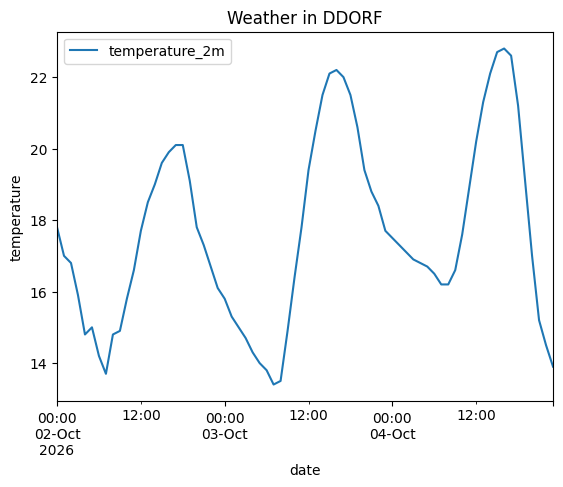

In [ ]:
df.plot(x = "time", y = "temperature_2m")

plt.title("Weather in DDORF")
plt.xlabel("date")
plt.ylabel("temperature")

In [ ]:
plt.show()